In [1]:
"""!sudo apt update
!sudo apt install -y cmake libomp-dev
!pip install --upgrade pip
!pip install git+https://github.com/carlosluis/stable-baselines3@fix_tests
!pip install gymnasium "numpy<2.0" pandas pandas-ta matplotlib "tensorflow<=2.16" scipy scikit-learn optuna"""

'!sudo apt update\n!sudo apt install -y cmake libomp-dev\n!pip install --upgrade pip\n!pip install git+https://github.com/carlosluis/stable-baselines3@fix_tests\n!pip install gymnasium "numpy<2.0" pandas pandas-ta matplotlib "tensorflow<=2.16" scipy scikit-learn optuna'

In [2]:
from utils.envs import load_dataset
import pandas as pd

In [3]:
df = load_dataset('utils/envs/stocks_data/CRM.csv')

In [4]:
df['Close']

0       159.50
1       161.11
2       161.78
3       162.86
4       162.60
         ...  
1253    291.37
1254    294.72
1255    298.01
1256    297.49
1257    306.90
Name: Close, Length: 1258, dtype: float64

In [5]:
X = df['Close'].pct_change()
X.iloc[0] = 0
X

0       0.000000
1       0.010094
2       0.004159
3       0.006676
4      -0.001596
          ...   
1253   -0.016970
1254    0.011497
1255    0.011163
1256   -0.001745
1257    0.031631
Name: Close, Length: 1258, dtype: float64

In [6]:
TP = 0.1      # Take Profit (10%)
SL = 0.05      # Stop Loss (5%)
W = 15    # Window size (look ahead W ticks)
MAX_OFFSET = len(df)  # Maximum offset (use the length of the data as the limit)

In [7]:
def calculate_B(i, X, TP, SL, W, MAX_OFFSET):
    t = 1
    for j in range(i + 1, min(i + W, MAX_OFFSET)):  # Loop within window size or MAX_OFFSET
        t *= (1 + X[j])
        if t - 1 >= TP or t - 1 <= -SL:
            return t - 1  # Return the profit/loss if the threshold is met
    return t - 1  # If the loop completes, return the final value of t - 1

# Step 3: Apply the function to calculate the 'B' indicator for each index
B = []
for idx, value in X.items():
    B.append(calculate_B(idx, X, TP, SL, W, MAX_OFFSET))

# Convert the result into a pandas Series (if needed)
B = pd.Series(B, index=X.index)

In [1]:
from sb3.combined_env import CombinedEnv
from utils.envs.sb3 import testing_env, create_custom_env

In [9]:
#env = CombinedEnv(df=df, window_size=10, frame_bound=(100, 140), no_action_punishment=0)

env = testing_env(no_action_punishment=0)

In [10]:
env.signal_features[0]

array([-0.87947583, -0.7009607 , -0.61825985, -0.09987906, -0.7142556 ,
        0.08096365, -0.08133861, -0.42629528, -0.17024407, -0.46686885,
       -0.03305986], dtype=float32)

In [11]:
len(env.B)

55

In [15]:
x = [x for x in env.B if x > 0]
y = [y for y in env.B_ if y > 0]

In [17]:
print(x)
print(y)

[0.06086551264980037, 0.06178244211227749, 0.0062770216172936336, 0.023323282018726833, 0.002048687954473473, 0.005553822152885947]
[0.04239014647137188, 0.03712810261535918, 0.0062770216172936336, 0.023323282018726833, 0.002048687954473473, 0.005553822152885947]


TypeError: 'NoneType' object is not iterable

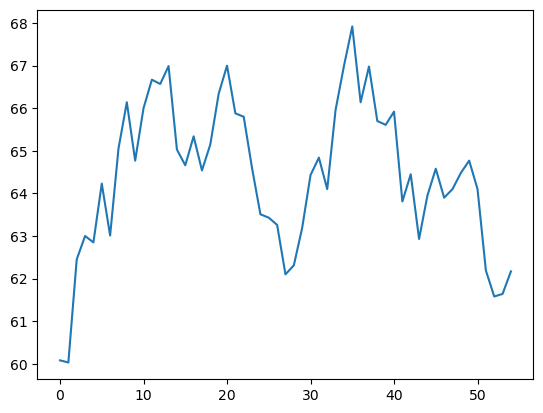

In [18]:
env.save_render("test.jpg")

TypeError: 'NoneType' object is not iterable

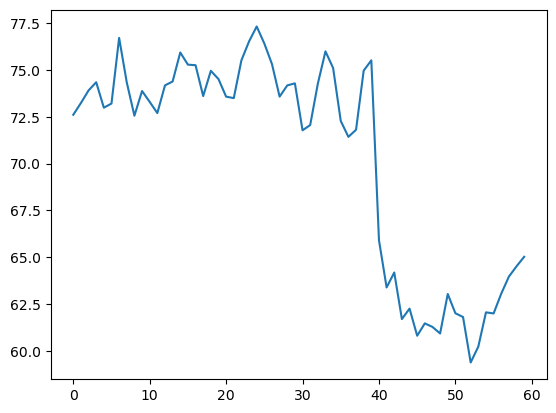

In [43]:
env = create_custom_env("PYPL", (850, 950), 0)
env.save_render("test.jpg")

In [25]:
X = env.df.loc[:, 'Close'].pct_change().to_numpy()

In [42]:
print(
    max([x for x in env.B_ if x > 0.04]),
    max([x for x in env.B if x > 0.04]),
)

0.08403452975920003 0.07585180686304208
